## Add available landcover information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
YEAR = 2023
MONTH = 'July'
PERIOD = '2nd'

In [5]:
#landcover data go up to 2021, update file when available

In [6]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv', encoding=enc)
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()


In [7]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-07-16,veneto,abano terme,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"19,349",46.86645,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,26.97,33.83,20.11,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,6.413500,34.178536,365.508363,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,54,0,0
1,12.04940,45.07048,2023-07-16,veneto,adria,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"20,233",46.65336,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,24.45,31.05,17.85,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,7.656067,40.872501,614.292642,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,161,0,0
2,10.77673,45.55680,2023-07-16,veneto,affi,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"2,297",46.81410,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,23.29,28.59,17.99,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,6.402151,74.657804,234.700794,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,29,0,0
3,11.96539,45.17531,2023-07-16,veneto,agna,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"3,400",46.73306,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,24.67,31.11,18.23,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,7.009414,22.983486,599.293707,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,146,0,0
4,12.05912,46.31399,2023-07-16,veneto,agordo,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,20,0,0


In [8]:
landcover.head()

,x,y,2001_01_01_lc_prop1,2001_01_01_lc_prop1_assessment,2001_01_01_lc_prop2,2001_01_01_lc_prop2_assessment,2001_01_01_lc_prop3,2001_01_01_lc_prop3_assessment,2001_01_01_lc_type1,2001_01_01_lc_type2,2001_01_01_lc_type3,2001_01_01_lc_type4,2001_01_01_lc_type5,2001_01_01_lw,2001_01_01_qc,2002_01_01_lc_prop1,2002_01_01_lc_prop1_assessment,2002_01_01_lc_prop2,2002_01_01_lc_prop2_assessment,2002_01_01_lc_prop3,2002_01_01_lc_prop3_assessment,2002_01_01_lc_type1,2002_01_01_lc_type2,2002_01_01_lc_type3,2002_01_01_lc_type4,2002_01_01_lc_type5,2002_01_01_lw,2002_01_01_qc,2003_01_01_lc_prop1,2003_01_01_lc_prop1_assessment,2003_01_01_lc_prop2,2003_01_01_lc_prop2_assessment,2003_01_01_lc_prop3,2003_01_01_lc_prop3_assessment,2003_01_01_lc_type1,2003_01_01_lc_type2,2003_01_01_lc_type3,2003_01_01_lc_type4,2003_01_01_lc_type5,2003_01_01_lw,2003_01_01_qc,2004_01_01_lc_prop1,2004_01_01_lc_prop1_assessment,2004_01_01_lc_prop2,2004_01_01_lc_prop2_assessment,2004_01_01_lc_prop3,2004_01_01_lc_prop3_assessment,2004_01_01_lc_type1,2004_01_01_lc_type2,2004_01_01_lc_type3,2004_01_01_lc_type4,2004_01_01_lc_type5,2004_01_01_lw,2004_01_01_qc,2005_01_01_lc_prop1,2005_01_01_lc_prop1_assessment,2005_01_01_lc_prop2,2005_01_01_lc_prop2_assessment,2005_01_01_lc_prop3,2005_01_01_lc_prop3_assessment,2005_01_01_lc_type1,2005_01_01_lc_type2,2005_01_01_lc_type3,2005_01_01_lc_type4,2005_01_01_lc_type5,2005_01_01_lw,2005_01_01_qc,2006_01_01_lc_prop1,2006_01_01_lc_prop1_assessment,2006_01_01_lc_prop2,2006_01_01_lc_prop2_assessment,2006_01_01_lc_prop3,2006_01_01_lc_prop3_assessment,2006_01_01_lc_type1,2006_01_01_lc_type2,2006_01_01_lc_type3,2006_01_01_lc_type4,2006_01_01_lc_type5,2006_01_01_lw,2006_01_01_qc,2007_01_01_lc_prop1,2007_01_01_lc_prop1_assessment,2007_01_01_lc_prop2,2007_01_01_lc_prop2_assessment,2007_01_01_lc_prop3,2007_01_01_lc_prop3_assessment,2007_01_01_lc_type1,2007_01_01_lc_type2,2007_01_01_lc_type3,2007_01_01_lc_type4,2007_01_01_lc_type5,2007_01_01_lw,2007_01_01_qc,2008_01_01_lc_prop1,2008_01_01_lc_prop1_assessment,2008_01_01_lc_prop2,2008_01_01_lc_prop2_assessment,2008_01_01_lc_prop3,2008_01_01_lc_prop3_assessment,2008_01_01_lc_type1,2008_01_01_lc_type2,2008_01_01_lc_type3,2008_01_01_lc_type4,2008_01_01_lc_type5,2008_01_01_lw,2008_01_01_qc,2009_01_01_lc_prop1,2009_01_01_lc_prop1_assessment,2009_01_01_lc_prop2,2009_01_01_lc_prop2_assessment,2009_01_01_lc_prop3,2009_01_01_lc_prop3_assessment,2009_01_01_lc_type1,2009_01_01_lc_type2,2009_01_01_lc_type3,2009_01_01_lc_type4,2009_01_01_lc_type5,2009_01_01_lw,2009_01_01_qc,2010_01_01_lc_prop1,2010_01_01_lc_prop1_assessment,2010_01_01_lc_prop2,2010_01_01_lc_prop2_assessment,2010_01_01_lc_prop3,2010_01_01_lc_prop3_assessment,2010_01_01_lc_type1,2010_01_01_lc_type2,2010_01_01_lc_type3,2010_01_01_lc_type4,2010_01_01_lc_type5,2010_01_01_lw,2010_01_01_qc,2011_01_01_lc_prop1,2011_01_01_lc_prop1_assessment,2011_01_01_lc_prop2,2011_01_01_lc_prop2_assessment,2011_01_01_lc_prop3,2011_01_01_lc_prop3_assessment,2011_01_01_lc_type1,2011_01_01_lc_type2,2011_01_01_lc_type3,2011_01_01_lc_type4,2011_01_01_lc_type5,2011_01_01_lw,2011_01_01_qc,2012_01_01_lc_prop1,2012_01_01_lc_prop1_assessment,2012_01_01_lc_prop2,2012_01_01_lc_prop2_assessment,2012_01_01_lc_prop3,2012_01_01_lc_prop3_assessment,2012_01_01_lc_type1,2012_01_01_lc_type2,2012_01_01_lc_type3,2012_01_01_lc_type4,2012_01_01_lc_type5,2012_01_01_lw,2012_01_01_qc,2013_01_01_lc_prop1,2013_01_01_lc_prop1_assessment,2013_01_01_lc_prop2,2013_01_01_lc_prop2_assessment,2013_01_01_lc_prop3,2013_01_01_lc_prop3_assessment,2013_01_01_lc_type1,2013_01_01_lc_type2,2013_01_01_lc_type3,2013_01_01_lc_type4,2013_01_01_lc_type5,2013_01_01_lw,2013_01_01_qc,2014_01_01_lc_prop1,2014_01_01_lc_prop1_assessment,2014_01_01_lc_prop2,2014_01_01_lc_prop2_assessment,2014_01_01_lc_prop3,2014_01_01_lc_prop3_assessment,2014_01_01_lc_type1,2014_01_01_lc_type2,2014_01_01_lc_type3,2014_01_01_lc_type4,2014_01_01_lc_type5,2014_01_01_lw,2014_01_01_qc,2015_01_01_lc_prop1,2015_01_01_lc_prop1_assessment,2015_01_01

In [9]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [10]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))


In [11]:
data_years = dataset['year'].unique().tolist()

In [12]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [13]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.022654405382625
Max distance: 1.369549141632771


In [14]:
dataset_final = pd.DataFrame()

In [15]:
for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

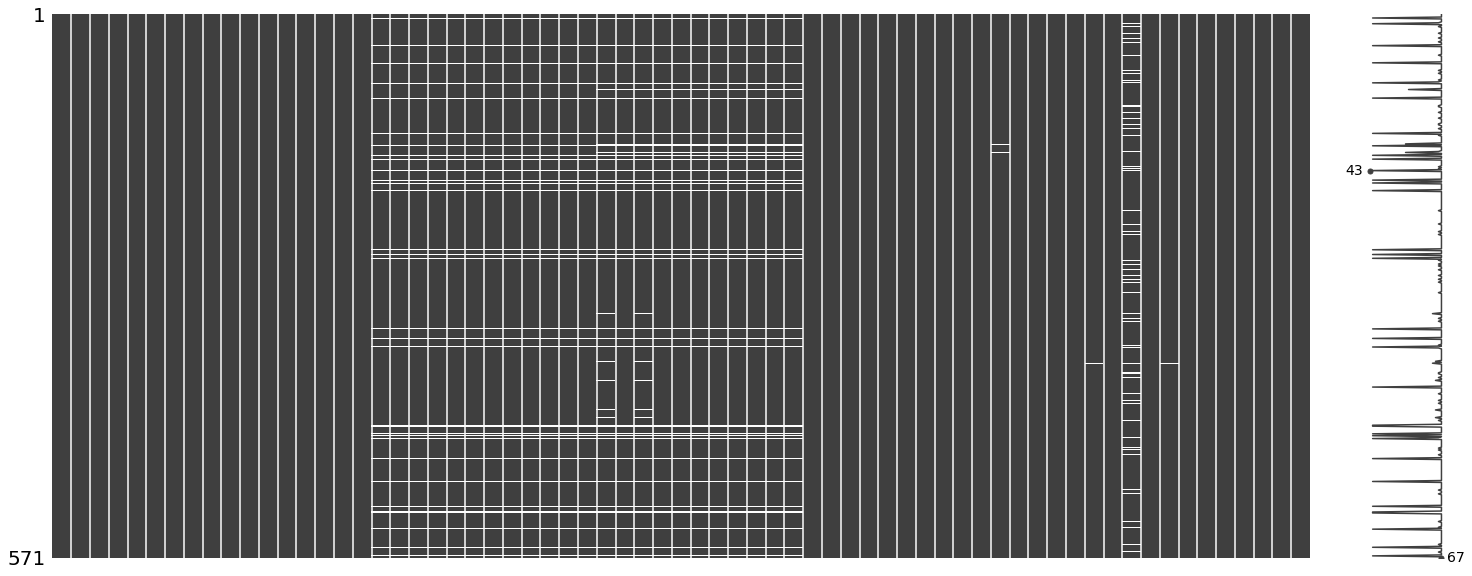

In [16]:
missingno.matrix(dataset_final)

In [17]:
cols = dataset_final.columns

In [18]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case', 'lc_prop1',
       'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 'lc_prop3',
       'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_typ

In [19]:
len(cols)

67

In [20]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [21]:
len(rearranged)

67

In [22]:
dataset_final = dataset_final[rearranged]

In [23]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)